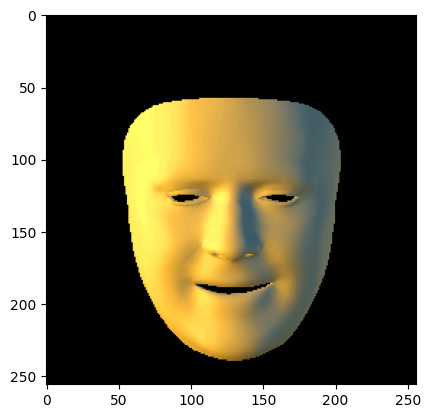

59.810767755126946
55.08093574829101


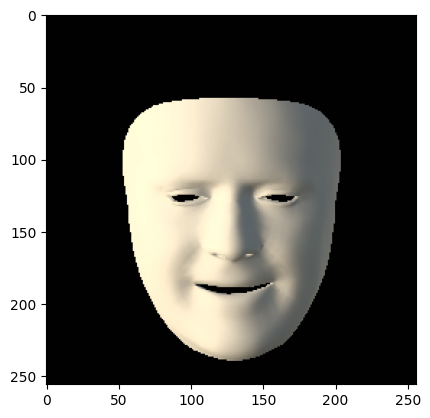

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def change_saturation(image_path, saturation_scale):
    """
    Loads an image, changes its saturation, and returns the result.

    Args:
        image_path (str): The path to the input image.
        saturation_scale (float): The factor to scale saturation by.
                                  > 1.0 increases saturation.
                                  < 1.0 decreases saturation.

    Returns:
        A new image with the adjusted saturation.
    """
    # Step 1: Load the image and convert to HSV
    img = cv2.imread(image_path)
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Separate the H, S, and V channels
    h, s, v = cv2.split(hsv_img)

    # Step 2: Modify the Saturation channel
    # Multiply the saturation channel by the scale factor
    # Convert to a float to prevent data loss during multiplication
    new_s = s.astype(np.float64) * saturation_scale

    # Clip the values to stay within the valid 0-255 range
    new_s = np.clip(new_s, 0, 255)

    # Convert back to the original 8-bit integer type
    s = new_s.astype(np.uint8)

    # Step 3: Merge the channels and convert back to BGR (OpenCV's default)
    final_hsv = cv2.merge([h, s, v])
    saturated_img = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)

    return saturated_img

def compute_luminance(image):
    L = image[..., 0] * 0.2126 + image[..., 1] * 0.7152 + image[..., 2] * 0.0722
    return L

# --- How to use it ---
# Load an image and make it more vibrant
img = '/data/mint/TPAMI_MajorRevision/Ours/ffhq_hdr/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_SD256_1.0C_sColor_rAxis2/ema_300000/valid/render_face_hdr/117_hdrmaps_com_free_2K/src=66744.jpg/dst=60000.jpg/Lerp_1000/n_frames=60/dst_ren_frame20.png'
more_vibrant_image = change_saturation(img, 2)[..., ::-1] # Increases saturation by 50%
plt.imshow(more_vibrant_image)
plt.show()

# Compute Luminance from RGB
L_org = compute_luminance(cv2.imread(img)[..., ::-1])
Lm = compute_luminance(more_vibrant_image)
print(np.mean(L_org))
print(np.mean(Lm))


# Load the same image and make it less vibrant (desaturate)
less_vibrant_image = change_saturation(img, 0.5) # Decreases saturation by 50%
plt.imshow(less_vibrant_image[..., ::-1])
plt.show()

# To display the images (if you have a desktop environment)
# cv2.imshow('More Vibrant', more_vibrant_image)
# cv2.imshow('Less Vibrant', less_vibrant_image)
# cv2.waitKey(0)
# cv2.destroyAllWindows()